In the file **Ride_history.csv** you will find data on the rentals of Wroclaw City Bicycles - you can find current data with column names in Polish [here](https://www.wroclaw.pl/open-data/dataset/wrmprzejazdy_data). If you have problems with Polish letters, the file is using "Windows-1250" encoding.

Read the data from the file, and then select only those where the rental and return stations are the same and the rentals are shorter than 100 minutes. Show on the graph how many rentals of a given duration there were (first bar: rentals with a duration of one minute, the second - two minutes, etc.).

Rentals that start and end at the same station and last no more than three minutes are probably rentals of defective bikes, which the user returns as soon as they realize the problem. Draw a red line that separates rentals shorter and longer than 3 minutes.

Also give it an annotation explaining what this line is.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../01_Data for plots/Ride_history.csv', encoding="cp1250")
df.head()


,Check-out UID,Bike number,Check-out time,Check-in time,Check out dock,Check in dock,Ride duration
0,112512738,57243,2021-03-03 23:41:47,2021-03-04 00:00:34,Plac Grunwaldzki / Polaka,Undocked,19
1,112512783,57434,2021-03-03 23:46:14,2021-03-04 00:00:41,Bezpieczna/Jugosławiańska,Kurkowa / Dubois,15
2,112512778,650040,2021-03-03 23:45:30,2021-03-04 00:02:33,al. Kochanowskiego / Kopernika,Rondo Reagana,18
3,112512869,57441,2021-03-03 23:53:59,2021-03-04 00:05:08,Plac Świętego Macieja / Trzebnicka,Nowowiejska / Górnickiego,12
4,112512830,651044,2021-03-03 23:50:10,2021-03-04 00:07:12,Powstańców Śląskich/Orla,Szewska / Kazimierza Wielkiego,18


1. Check DataFrame

In [4]:
df.shape

(3067, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3067 entries, 0 to 3066
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Check-out UID   3067 non-null   int64 
 1   Bike number     3067 non-null   int64 
 2   Check-out time  3067 non-null   object
 3   Check-in time   3067 non-null   object
 4   Check out dock  3067 non-null   object
 5   Check in dock   3067 non-null   object
 6   Ride duration   3067 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 167.9+ KB


In [7]:
df.describe()

,Check-out UID,Bike number,Ride duration
count,3.067000e+03,3067.000000,3067.000000
mean,1.125308e+08,418781.620476,21.958265
std,1.245526e+04,289494.922969,286.152307
min,1.121464e+08,57001.000000,1.000000
25%,1.125227e+08,57642.500000,7.000000
50%,1.125316e+08,650239.000000,11.000000
75%,1.125386e+08,650795.000000,16.000000
max,1.125490e+08,651469.000000,15434.000000


2. Filter neccesary information

In [ ]:
# Keeping rides that have the same rent locations
# duration less 100 minutes

df_ride_dur = df.loc[
    (df['Ride duration'] < 100) &
    (df['Check in dock'] == df['Check out dock'])
    ]
df_ride_dur

,Check-out UID,Bike number,Check-out time,Check-in time,Check out dock,Check in dock,Ride duration
7,112512995,57280,2021-03-04 00:08:56,2021-03-04 00:10:20,Nowowiejska / Wyszyńskiego,Nowowiejska / Wyszyńskiego,2
20,112512900,57632,2021-03-03 23:56:37,2021-03-04 00:34:42,Kraszewskiego / Trzebnicka,Kraszewskiego / Trzebnicka,39
25,112513200,57610,2021-03-04 00:41:15,2021-03-04 00:44:13,Nowowiejska / Górnickiego,Nowowiejska / Górnickiego,3
48,112513459,57539,2021-03-04 01:43:28,2021-03-04 01:45:25,Krakowska / Leroy Merlin,Krakowska / Leroy Merlin,2
58,112513595,650148,2021-03-04 02:23:07,2021-03-04 02:25:12,Kamienna / Borowska (Aquapark),Kamienna / Borowska (Aquapark),3
...,...,...,...,...,...,...,...
3018,112548562,650780,2021-03-04 23:06:20,2021-03-04 23:08:19,Nowowiejska / Jedności Narodowej,Nowowiejska / Jedności Narodowej,2
3026,112548555,650302,2021-03-04 23:05:43,2021-03-04 23:15:01,Undocked,Undocked,10
3028,112548557,57727,2021-03-04 23:05:57,2021-03-04 23:17:49,Kościuszki / Komuny Paryskiej / Zgodna,Kościuszki / Komuny Paryskiej / Zgodna,12
3029,112548561,651320,2021-03-04 23:06:18,2021-03-04 23:17:54,Kościuszki / Komuny Paryskiej / Zgodna,Kościuszki / Komuny Paryskiej / Zgodna,12


In [20]:
df_ride_dur.info()

<class 'pandas.core.frame.DataFrame'>
Index: 436 entries, 7 to 3060
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Check-out UID   436 non-null    int64 
 1   Bike number     436 non-null    int64 
 2   Check-out time  436 non-null    object
 3   Check-in time   436 non-null    object
 4   Check out dock  436 non-null    object
 5   Check in dock   436 non-null    object
 6   Ride duration   436 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 27.2+ KB


In [29]:
# Number of rides for each duration (1 min, 2 min, etc)

duration_count = (
    df_ride_dur['Ride duration']
    .value_counts()
    .sort_index()
)
duration_count

Ride duration
1     99
2     56
3     49
4     18
5     16
6     12
7     10
8     13
9     14
10     7
11    10
12     8
13    11
14     1
15    11
16     4
17    12
18     8
19     5
20    11
21     2
24     3
25     1
26     1
27     4
28     3
29     2
31     1
32     1
34     3
36     1
37     2
39     1
40     2
41     6
42     1
46     2
48     1
51     1
53     1
55     2
57     2
59     1
60     2
63     1
72     1
83     1
91     1
92     1
Name: count, dtype: int64

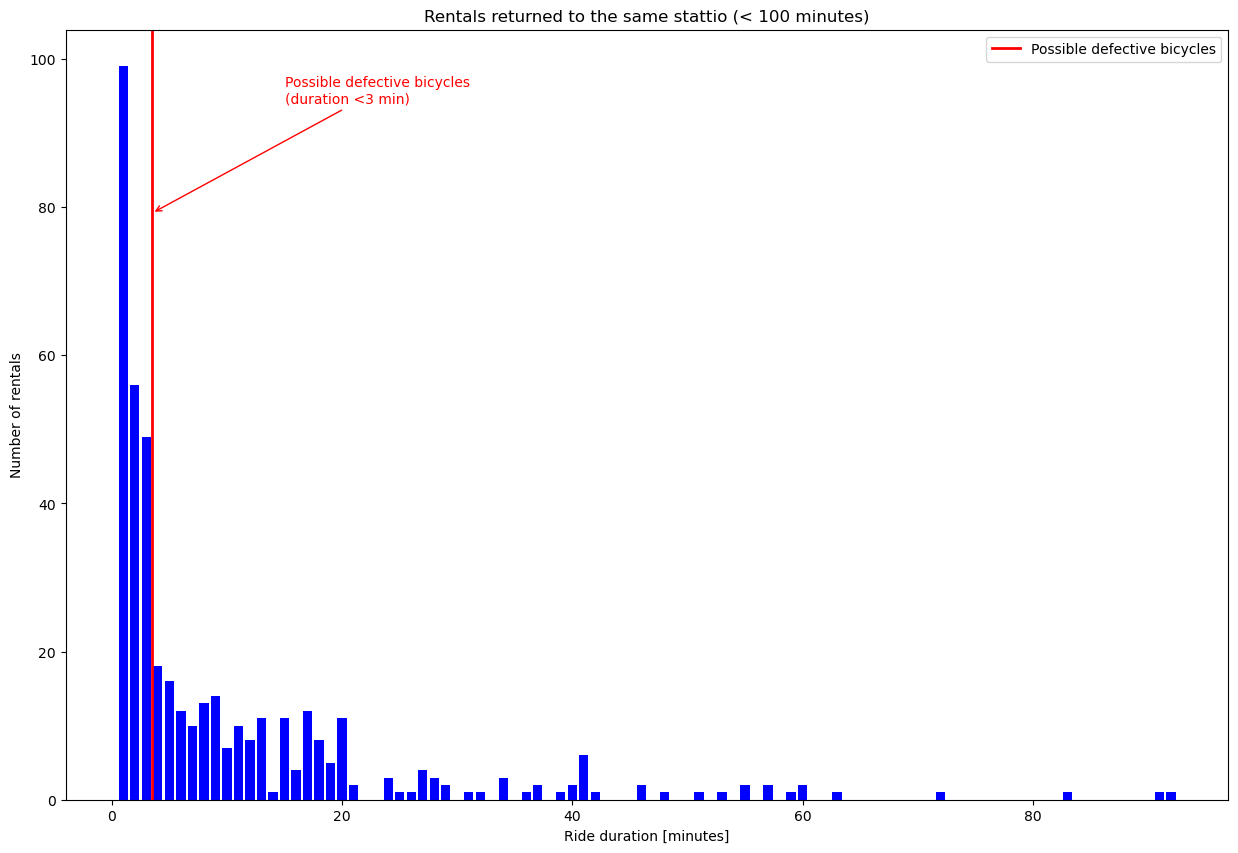

In [40]:
# Figure

plt.figure(figsize=(15, 10))

plt.bar(
    duration_count.index,
    duration_count.values,
    color='blue',
        )

# Duration dividing line

plt.axvline(
    x = 3.5,
    color = "red",
    linewidth = 2,
    label = "Possible defective bicycles"
)

# Annotation

plt.annotate(
    "Possible defective bicycles\n(duration <3 min)",
    xy = (3.5, duration_count.max() * 0.8), # Arrow pointing place
    xytext = (15,duration_count.max() * 0.95), # Position of the text
    color="red",
    arrowprops=dict(
        arrowstyle='->',
        color='red'
    )
)

plt.title("Rentals returned to the same stattio (< 100 minutes)")
plt.xlabel("Ride duration [minutes]")
plt.ylabel("Number of rentals")
plt.legend()